In [2]:
!pip install nltk

   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/1.8 MB ? eta -:--:--
   ----------------- ---------------------- 0.8/1.8 MB 2.4 MB/s eta 0:00:01
   ---------------------------------- ----- 1.6/1.8 MB 2.6 MB/s eta 0:00:01
   ---------------------------------------- 1.8/1.8 MB 2.6 MB/s  0:00:00

   ---------------------------------------- 0/5 [tqdm]
   ---------------------------------------- 0/5 [tqdm]
   -------- ------------------------------- 1/5 [regex]
   -------- ------------------------------- 1/5 [regex]
   ---------------- ----------------------- 2/5 [joblib]
   ---------------- ----------------------- 2/5 [joblib]
   ---------------- ----------------------- 2/5 [joblib]
   ---------------- ----------------------- 2/5 [joblib]
   ---------------- ----------------------- 2/5 [joblib]
   ---------------- ----------------------- 2/5 [joblib]
   ------------------------ --------------- 3/5 [click]
   -------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [3]:
import nltk
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
nltk.download('twitter_samples')
nltk.download('vader_lexicon')

[nltk_data] Downloading package twitter_samples to C:\Users\mehwish
[nltk_data]     shaheen\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\twitter_samples.zip.
[nltk_data] Downloading package vader_lexicon to C:\Users\mehwish
[nltk_data]     shaheen\AppData\Roaming\nltk_data...


True

In [5]:
from nltk.corpus import twitter_samples
positive_tweets = twitter_samples.strings('positive_tweets.json')
negative_tweets = twitter_samples.strings('negative_tweets.json')

In [6]:
pos_df = pd.DataFrame({'text': positive_tweets, 'actual_label': 'positive'})
neg_df = pd.DataFrame({'text': negative_tweets, 'actual_label': 'negative'})
df = pd.concat([pos_df, neg_df], ignore_index=True)
print(df.shape)

(10000, 2)


In [7]:
display(df.head())

,text,actual_label
0,#FollowFriday @France_Inte @PKuchly57 @Milipol...,positive
1,@Lamb2ja Hey James! How odd :/ Please call our...,positive
2,@DespiteOfficial we had a listen last night :)...,positive
3,@97sides CONGRATS :),positive
4,yeaaaah yippppy!!! my accnt verified rqst has...,positive


In [8]:
from nltk.sentiment import SentimentIntensityAnalyzer
sia = SentimentIntensityAnalyzer()

In [9]:
def get_sentiment_score(text):
    return sia.polarity_scores(text)['compound']

df['compound_score'] = df['text'].apply(get_sentiment_score)

In [10]:
def classify_sentiment(score):
    if score > 0.05:
        return 'positive'
    elif score < -0.05:
        return 'negative'
    else:
        return 'neutral'

df['predicted_label'] = df['compound_score'].apply(classify_sentiment)

In [11]:
print(df['predicted_label'].value_counts())

predicted_label
positive    5536
negative    3673
neutral      791
Name: count, dtype: int64


In [12]:
matches = df[df['actual_label'] == df['predicted_label']]
accuracy = len(matches) / len(df) * 100
print(f"Accuracy vs known labels: {accuracy:.2f}%")

Accuracy vs known labels: 80.29%


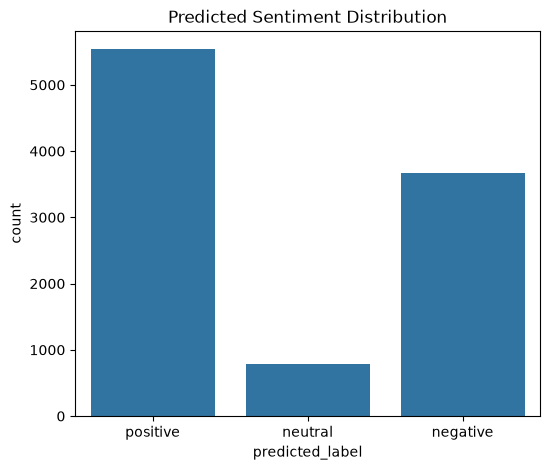

In [13]:
plt.figure(figsize=(6,5))
sns.countplot(x='predicted_label', data=df, order=['positive','neutral','negative'])
plt.title("Predicted Sentiment Distribution")
plt.show()

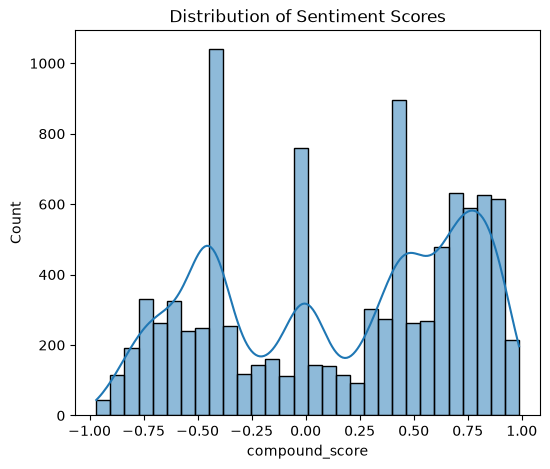

In [14]:
plt.figure(figsize=(6,5))
sns.histplot(df['compound_score'], bins=30, kde=True)
plt.title("Distribution of Sentiment Scores")
plt.show()

In [15]:
display(df[['text', 'actual_label', 'predicted_label', 'compound_score']].sample(10))

,text,actual_label,predicted_label,compound_score
932,ricky_febs Follback ya :),positive,positive,0.4588
5725,omg I wanna hear ghost stories :(,negative,negative,-0.6369
9350,"@adlow76 :( I wanted it to be good, or at leas...",negative,neutral,0.0000
3818,@jaewontrash Can i have his instagram? :)),positive,neutral,0.0000
7145,i feel you :(( https://t.co/jliVpKmFwG,negative,neutral,0.0000
3609,@VegPlotPeach Unfortunately we don't I'm sorry...,positive,positive,0.9188
4533,@lazybull81 also come game with me :),positive,positive,0.4588
1880,Happy 30th wedding anniversary to my folks :),positive,positive,0.7717
6440,":( ♫ Sad by @maroon5 (with zikra, Lusi, and Ha...",negative,negative,-0.7184
8793,"@Espio1 @scully1888 It's madness, for sure. Th...",negative,negative,-0.5423


In [16]:
print("Sentiment Analysis Insights")
print(f"1. Total texts analyzed: {len(df)}")
print(f"2. Predicted positive: {(df['predicted_label']=='positive').sum()}")
print(f"3. Predicted negative: {(df['predicted_label']=='negative').sum()}")
print(f"4. Predicted neutral: {(df['predicted_label']=='neutral').sum()}")
print(f"5. Model accuracy against known labels: {accuracy:.2f}%")

Sentiment Analysis Insights
1. Total texts analyzed: 10000
2. Predicted positive: 5536
3. Predicted negative: 3673
4. Predicted neutral: 791
5. Model accuracy against known labels: 80.29%


In [17]:
print("Task 4 Summary")
print("Used NLTK's VADER sentiment analyzer on a labeled Twitter dataset")
print("Classified text as positive, negative, or neutral using compound polarity scores")
print(f"Achieved {accuracy:.2f}% agreement with known ground-truth labels")

Task 4 Summary
Used NLTK's VADER sentiment analyzer on a labeled Twitter dataset
Classified text as positive, negative, or neutral using compound polarity scores
Achieved 80.29% agreement with known ground-truth labels
